In [ ]:
import json

import pandas as pd
import geopandas as gpd
from plot_ellipticity import plot_stops
from determine_stop_polygons import ellipticity, determine_concave_area

In [4]:
CITY = "budapest"
VERSION = "20250428"

In [5]:
stops = pd.read_csv(f"../data/stops/{CITY}/{VERSION}/stops_with_centrality.csv")

## Get cluster centroids by calculating mean of lat and lon

And create lookup tables (c2lat, c2lon) for replacing latitude and longitudes in clusters to the centroid.

In [32]:
def get_cluster_centroid(x) -> tuple[float, float]:
    lat = x["stop_lat"].mean()
    lon = x["stop_lon"].mean()
    return lon, lat

clust2latlon = stops.groupby(["clust"]).apply(get_cluster_centroid, include_groups=False).reset_index()
clust2latlon.columns = ["clust", "lonlat"]

c2lat = {}
c2lon = {}
for row in clust2latlon.itertuples():
    c2lat[row.clust] = row.lonlat[1]
    c2lon[row.clust] = row.lonlat[0]

In [ ]:
# stops.set_index("clust").groupby(level="clust").apply(get_cluster_centroid)

## Create a lookup table (c2s) for replacing stop IDs in clusters

In [ ]:
clust2stop = stops.sort_values(["clust", "stop_id"]).drop_duplicates(subset=["clust"], keep="first")[["clust", "stop_id"]].copy()
c2s = {}
for row in clust2stop.itertuples():
    c2s[row.clust] = row.stop_id

## Replace values in a copy

In [ ]:
clustered_stops = stops.copy()
clustered_stops = clustered_stops.drop_duplicates(subset=["clust"]).copy()

In [42]:
clustered_stops["stop_id"] = clustered_stops["clust"].map(c2s)
clustered_stops["stop_lat"] = clustered_stops["clust"].map(c2lat)
clustered_stops["stop_lon"] = clustered_stops["clust"].map(c2lon)

### Remove unnecessary columns

In [45]:
clustered_stops = clustered_stops.drop(columns=["Node", "Eigenvector Centrality", "Degree Centrality", "Closeness Centrality", "Betweenness Centrality"]).copy()

In [46]:
clustered_stops.to_csv(f"../output/{CITY}/{VERSION}/clustered_stops.csv", index=False)

In [ ]:
with open(
    f"../data/stops/{CITY}/{VERSION}/accessible_stops.json", "r"
) as fp:
    accessible_stops = json.load(fp)

In [ ]:
stop2stop = stops.sort_values(["clust", "stop_id"]).copy()
stop2stop["clust"] = stop2stop["clust"].map(c2s)

s2s = {}
for row in stop2stop[["stop_id", "clust"]].itertuples():
    s2s[row.stop_id] = row.clust


In [98]:
def recluster_accessible_stops(accessible_stops: dict[str, list[str]], mapper: dict) -> dict[str, list[str]]:
    result = {}
    for k, v in accessible_stops.items():
        if s2s[k] not in result:
            result[s2s[k]] = []
        for vv in v:
            result[s2s[k]].append(s2s[vv])
    return result


In [ ]:
clusetered_accessible_stops = recluster_accessible_stops(accessible_stops, s2s)

In [70]:
clustered_stops = gpd.GeoDataFrame(clustered_stops, geometry=gpd.points_from_xy(clustered_stops["stop_lon"], clustered_stops["stop_lat"]), crs=4326)

In [71]:
determine_concave_area(clustered_stops, clusetered_accessible_stops)

,stop_id,concave_area
0,007877,2.542
1,007879,1.371
2,007881,2.306
3,007883,2.273
4,007884,20.367
...,...,...
1959,F04564,5.708
1960,F04566,2.698
1961,F04568,9.280
1962,F04570,3.142


In [76]:
clusetered_accessible_stops["009537"]

['CSF01019',
 '008218',
 'F00951',
 'F00918',
 'F01161',
 '008546',
 '008782',
 '008590',
 '008546',
 '072934',
 'CSF01019',
 '008546',
 '009365',
 'F00004',
 '008590',
 '009537',
 '007884',
 'F00103',
 '062759',
 '062759',
 '008218',
 'CSF01019',
 '008238',
 '009537',
 '062759',
 '008546',
 'F00082',
 'CS056230',
 '008546',
 '062759',
 'F01111',
 '009537',
 '008782',
 'F00083',
 '007884',
 '008590',
 'F00102',
 'F00076',
 '008218',
 '072934',
 '008238',
 '008694',
 'F01110',
 '007950',
 'F00979',
 'CSF00097',
 '008546',
 'CSF01019',
 'F01110',
 'F00966',
 '008590',
 'F00979',
 '008590',
 'F00106',
 'F00942',
 '099342',
 'F00918',
 'CSF01019',
 '008238',
 '008782',
 '008782',
 'F00091',
 '009365',
 'F00966',
 'F00076',
 '008546',
 'F00982',
 '062759',
 '008590',
 '048505',
 '009041',
 'F00028',
 'F00951',
 '062759',
 'F02152',
 'F00099',
 '008782',
 '008546',
 'F02148',
 '008546',
 '008782',
 '099342',
 'CSF01019',
 '007950',
 '072934',
 '008782',
 'CSF01019',
 'F00918',
 '008590',
 '0

In [85]:
el = {}
ellipticity_threshold: int = 2
for k, v in clusetered_accessible_stops.items():
    accessible_stop_list = clustered_stops[clustered_stops["stop_id"].isin(v)].geometry.to_list()
    el[k] = ellipticity(accessible_stop_list, threshold=ellipticity_threshold)

In [88]:
clustered_stops["ellipticity"] = clustered_stops["stop_id"].map(el)

In [89]:
clustered_stops

,stop_id,stop_name,stop_lat,stop_lon,clust,geometry,ellipticity
0,007877,Bíróság,47.519481,18.978040,2120,POINT (18.97804 47.51948),0.8732
2,007879,"Római úti lakótelep, Varsa utca",47.570863,19.058543,1752,POINT (19.05854 47.57086),0.4449
3,007881,Váradi utca,47.543646,19.030374,1947,POINT (19.03037 47.54365),0.6903
4,007883,Perényi út,47.546281,19.029387,1973,POINT (19.02939 47.54628),0.5778
5,007884,Deák Ferenc tér M,47.497644,19.054530,366,POINT (19.05453 47.49764),0.4044
...,...,...,...,...,...,...,...
4439,F04564,Erzsébeti temető,47.418649,19.122355,1135,POINT (19.12236 47.41865),0.2452
4441,F04566,Tangazdaság (Óvoda),47.390799,19.159484,986,POINT (19.15948 47.3908),0.8281
4443,F04568,Erzsébet utca,47.402997,19.115640,1010,POINT (19.11564 47.403),0.3310
4445,F04570,Ócsai úti felüljáró,47.383515,19.125709,995,POINT (19.12571 47.38351),0.5467


## Plot stop ellipticity

In [93]:
boundary = gpd.read_file(f"../data/osm/{CITY}/boundary.geojson").to_crs(23700)
boundary_polygon = boundary.geometry[0]

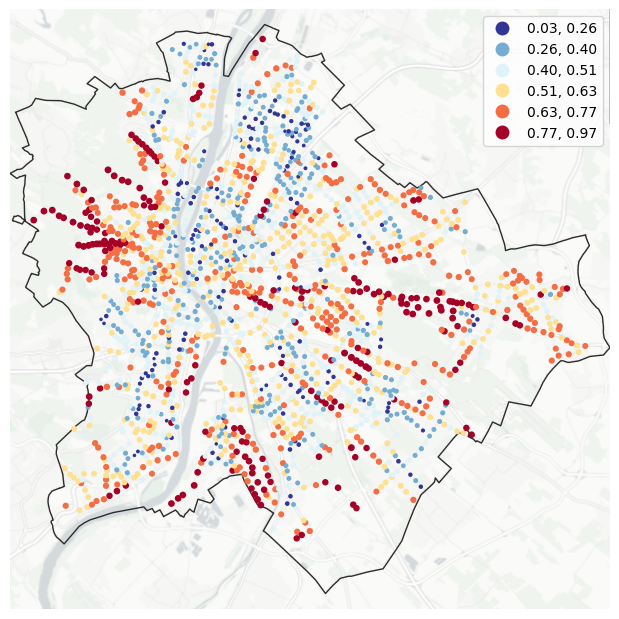

In [97]:
fig, ax = plot_stops(
    gpd.clip(clustered_stops.to_crs(23700), boundary_polygon).query("ellipticity.notna()"),
    boundary,
    "ellipticity",
    crs=23700,
)